<a href="https://colab.research.google.com/github/yadavrishikesh/yadavrishikesh.github.io/blob/master/MA563_Lab1_RandomNumberGeneration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MA 563 - Statistical Computation and Simulation
## Lab 1: Random Number Generation and Simulation Foundations

Instructor: Dr. Rishikesh Yadav  |  TA: Vedant Vibhor

---

This lab is the computational companion to **Module 1** of the lecture slides. Everything
we build here rests on one idea: a stream of i.i.d. $\mathrm{Uniform}(0,1)$ numbers is the
*universal raw material* from which every other distribution is manufactured.

| Part | Topic | Slides |
|:--|:--|:--|
| 1 | A toy Linear Congruential Generator with tunable $(m, a, c, X_0)$ | 7–9 |
| 2 | The lattice structure problem (Marsaglia's theorem) | 10 |
| 3 | Inverse transform: Exponential, Cauchy, Weibull, Pareto, Binomial, Geometric | 14–18 |
| 4 | Acceptance–rejection: Normal from Cauchy, Beta(2,2), truncated Normal | 19–24 |

In [ ]:
# ------------------------------------------------------------------
# Setup: run this cell first.
# ------------------------------------------------------------------
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Plot defaults (kept minimal so the statistics, not the styling, are the point).
plt.rcParams.update({
    "figure.figsize": (10, 3.6),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

BLUE, ORANGE, GREEN = "#003366", "#ED7D31", "#2E7D32"

# A trustworthy modern PRNG (PCG64), used ONLY as the "ground truth" reference
# against which we compare our hand-rolled generators.
rng = np.random.default_rng(seed=2026)

print("Setup complete. numpy", np.__version__)

Setup complete. numpy 2.3.2


---
# Part 1 - A Toy Linear Congruential Generator

> $$X_{n+1} = (a X_n + c) \bmod m, \qquad U_n = X_n / m$$

Four knobs, nothing else:

| Symbol | Name | Constraint |
|:--|:--|:--|
| $m$ | modulus | $m > 0$ |
| $a$ | multiplier | $0 \le a < m$ |
| $c$ | increment | $0 \le c < m$ ( $c=0 \Rightarrow$ *multiplicative* generator ) |
| $X_0$ | seed | $0 \le X_0 < m$ |

The sequence is 100% deterministic. The whole art is choosing $(m,a,c)$ so that the output
*looks* like independent uniform noise for far longer than you will ever need it.

In [ ]:
# ------------------------------------------------------------------
# 1.1  The generator itself.
#      Written as a plain Python loop for readability, not for speed --
#      the recurrence is inherently sequential anyway.
# ------------------------------------------------------------------

def lcg(n, m, a, c, seed, uniform=True, include_seed=False):
    """Generate n numbers from the LCG X_{k+1} = (a*X_k + c) mod m.

    Parameters
    ----------
    n           : how many numbers to return
    m, a, c     : modulus, multiplier, increment
    seed        : X_0, the starting state
    uniform     : if True return U_k = X_k / m in (0,1); if False return the raw integers
    include_seed: if True the returned sequence starts at X_0, else at X_1

    Returns
    -------
    numpy array of length n
    """
    # Basic sanity checks -- catching a bad call here saves a lot of confusion later.
    assert m > 0, "modulus m must be positive"
    assert 0 <= a < m, "need 0 <= a < m"
    assert 0 <= c < m, "need 0 <= c < m"
    assert 0 <= seed < m, "need 0 <= X_0 < m"

    x = seed
    out = []
    if include_seed:
        out.append(x)
    while len(out) < n:
        x = (a * x + c) % m      # <-- the entire generator, one line
        out.append(x)

    arr = np.array(out, dtype=np.int64)
    return arr / m if uniform else arr

In [ ]:
# ------------------------------------------------------------------
# 1.2  Reproduce the slide-9 table exactly.
#      Expected: X_n = 7, 6, 1, 8, 11, 10  and  U_n = X_n / 16
# ------------------------------------------------------------------
X = lcg(6, m=16, a=5, c=3, seed=7, uniform=False, include_seed=True)
U = X / 16

table = pd.DataFrame({"n": np.arange(6), "X_n": X, "U_n = X_n/16": U}).set_index("n").T
display(table)

n,0,1,2,3,4,5
X_n,7.0000,6.000,1.0000,8.0,11.0000,10.000
U_n = X_n/16,0.4375,0.375,0.0625,0.5,0.6875,0.625


### 1.3 Hull-Dobell: when does the LCG hit *every* state?

**Theorem (Hull–Dobell, 1962).** A mixed LCG ($c \neq 0$) has **full period $m$** if and only if

1. $\gcd(c, m) = 1$;
2. $a - 1$ is divisible by every prime factor of $m$;
3. $a - 1$ is divisible by 4 whenever $m$ is divisible by 4.

Full period is *necessary but nowhere near sufficient* for quality — a generator can visit
all $m$ states and still be statistically awful (we meet exactly such a generator in Part 2).

Note the theorem says nothing about $c = 0$ generators such as Park–Miller; those are
governed by a different result (period $m-1$ when $m$ is prime and $a$ is a primitive root
modulo $m$).

In [ ]:
# ------------------------------------------------------------------
# 1.3  A Hull-Dobell checker + an empirical period finder.
# ------------------------------------------------------------------

def prime_factors(n):
    """Return the set of distinct prime factors of n (trial division; fine for small n)."""
    factors, d = set(), 2
    while d * d <= n:
        while n % d == 0:
            factors.add(d)
            n //= d
        d += 1
    if n > 1:
        factors.add(n)
    return factors


def hull_dobell(m, a, c, verbose=True):
    """Check the three Hull-Dobell conditions. Returns True iff the LCG has full period m."""
    if c == 0:
        if verbose:
            print("c = 0: Hull-Dobell does not apply (multiplicative generator, max period m-1).")
        return False

    cond1 = math.gcd(c, m) == 1
    cond2 = all((a - 1) % p == 0 for p in prime_factors(m))
    cond3 = (a - 1) % 4 == 0 if m % 4 == 0 else True

    if verbose:
        mark = lambda b: "PASS" if b else "FAIL"
        print(f"LCG(m={m}, a={a}, c={c})")
        print(f"  1. gcd(c, m) = {math.gcd(c, m)} == 1 ................. {mark(cond1)}")
        print(f"  2. (a-1)={a-1} divisible by primes {sorted(prime_factors(m))} .. {mark(cond2)}")
        print(f"  3. m % 4 == 0 => 4 | (a-1) ...................... {mark(cond3)}")
        print(f"  => full period {m}: {cond1 and cond2 and cond3}")
    return cond1 and cond2 and cond3


def empirical_period(m, a, c, seed, max_steps=None):
    """Find the true period by iterating until a state repeats (only for small m!)."""
    max_steps = max_steps or (m + 5)
    seen, x = {}, seed
    for step in range(max_steps):
        if x in seen:
            return step - seen[x]          # length of the cycle we just closed
        seen[x] = step
        x = (a * x + c) % m
    return None


# The toy generator from the slides -- all three conditions hold, so period should be 16.
hull_dobell(m=16, a=5, c=3)
print("empirical period:", empirical_period(16, 5, 3, seed=7))

LCG(m=16, a=5, c=3)
  1. gcd(c, m) = 1 == 1 ................. PASS
  2. (a-1)=4 divisible by primes [2] .. PASS
  3. m % 4 == 0 => 4 | (a-1) ...................... PASS
  => full period 16: True
empirical period: 16


In [ ]:
# ------------------------------------------------------------------
# 1.4  Break it on purpose: what a failed condition costs you.
#      Same modulus m = 16, only a and c change.
# ------------------------------------------------------------------
candidates = [
    (16,  5,  3, "all three conditions hold"),
    (16,  5,  4, "condition 1 fails: gcd(4,16)=4"),
    (16,  3,  3, "condition 3 fails: 4 does not divide a-1=2"),
    (16,  6,  3, "condition 2 fails: 2 does not divide a-1=5"),
    (16,  1,  1, "trivial 'counter' -- full period but useless"),
]

rows = []
for m, a, c, note in candidates:
    full = hull_dobell(m, a, c, verbose=False)
    per  = empirical_period(m, a, c, seed=7)
    seq  = lcg(8, m, a, c, seed=7, uniform=False)
    rows.append({"m": m, "a": a, "c": c, "Hull-Dobell": full,
                 "period": per, "first 8 states": list(seq), "note": note})

display(pd.DataFrame(rows))

print("\nRead the 'period' column: a short period means the SAME numbers come back")
print("again and again. Any Monte Carlo estimate then stops improving no matter how")
print("many 'extra' draws you take -- you are averaging the same handful of values.")

,m,a,c,Hull-Dobell,period,first 8 states,note
0,16,5,3,True,16,"[6, 1, 8, 11, 10, 5, 12, 15]",all three conditions hold
1,16,5,4,False,1,"[7, 7, 7, 7, 7, 7, 7, 7]","condition 1 fails: gcd(4,16)=4"
2,16,3,3,False,8,"[8, 11, 4, 15, 0, 3, 12, 7]",condition 3 fails: 4 does not divide a-1=2
3,16,6,3,False,1,"[13, 1, 9, 9, 9, 9, 9, 9]",condition 2 fails: 2 does not divide a-1=5
4,16,1,1,True,16,"[8, 9, 10, 11, 12, 13, 14, 15]",trivial 'counter' -- full period but useless



Read the 'period' column: a short period means the SAME numbers come back
again and again. Any Monte Carlo estimate then stops improving no matter how
many 'extra' draws you take -- you are averaging the same handful of values.


### 1.5 Your own generator with visualizations

Change `M_MOD`, `A_MULT`, `C_INC`, `SEED` below and re-run. Things worth trying:

* `M_MOD = 2**31 - 1, A_MULT = 16807, C_INC = 0` — the **Park–Miller / Lehmer** generator
  from the slides.
* `M_MOD = 2048, A_MULT = 65, C_INC = 1` — full period, but keep it in mind for Part 2.
* `M_MOD = 100, A_MULT = 21, C_INC = 3` — a modulus so small the histogram becomes a comb.

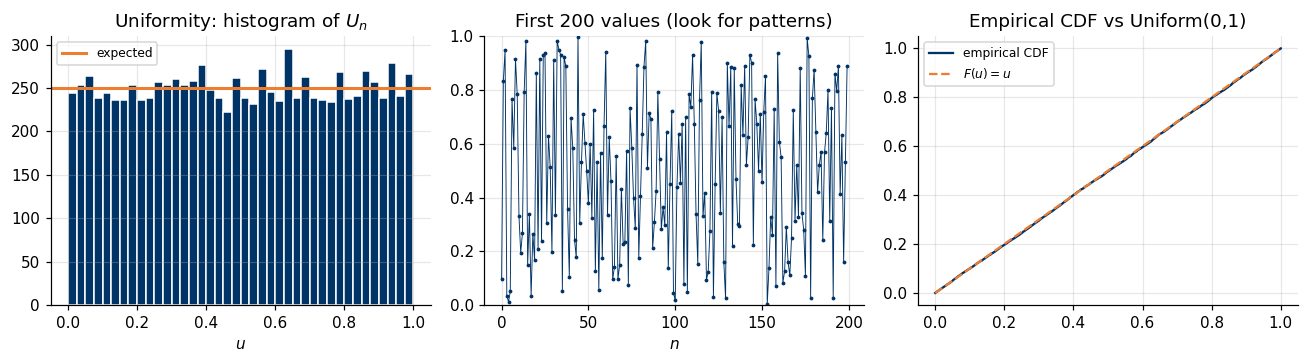

In [ ]:
# ------------------------------------------------------------------
# 1.5  TUNE ME -- edit the four parameters, re-run, look at the diagnostics.
# ------------------------------------------------------------------
M_MOD  = 2**31 - 1     # modulus m
A_MULT = 16807         # multiplier a
C_INC  = 0             # increment c  (0 => multiplicative generator)
SEED   = 12345         # X_0
N_DRAW = 10_000        # how many U's to generate
# ------------------------------------------------------------------

u = lcg(N_DRAW, M_MOD, A_MULT, C_INC, SEED)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))

# (a) Histogram: is the output spread evenly over (0,1)?
ax[0].hist(u, bins=40, range=(0, 1), color=BLUE, edgecolor="white")
ax[0].axhline(N_DRAW / 40, color=ORANGE, lw=2, label="expected")
ax[0].set_title("Uniformity: histogram of $U_n$")
ax[0].set_xlabel("$u$"); ax[0].legend(fontsize=8)

# (b) Trace of the first 200 values: any drift, cycling or banding?
ax[1].plot(u[:200], ".-", color=BLUE, lw=0.6, ms=3)
ax[1].set_ylim(0, 1); ax[1].set_title("First 200 values (look for patterns)")
ax[1].set_xlabel("$n$")

# (c) Empirical CDF vs the straight line of a true Uniform(0,1).
xs = np.sort(u)
ax[2].plot(xs, np.arange(1, N_DRAW + 1) / N_DRAW, color=BLUE, lw=1.5, label="empirical CDF")
ax[2].plot([0, 1], [0, 1], "--", color=ORANGE, lw=1.5, label="$F(u)=u$")
ax[2].set_title("Empirical CDF vs Uniform(0,1)")
ax[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

---
# Part 2 - The Lattice Structure Problem

> **Marsaglia (1968).** *"Random numbers fall mainly in the planes."*
> Overlapping $k$-tuples $(U_n, U_{n+1}, \dots, U_{n+k-1})$ from an LCG do **not** fill the
> $k$-dimensional unit cube. They lie on a relatively small number of parallel hyperplanes.

Why it must happen, in one line. For a multiplicative generator $X_{n+1} = aX_n \bmod m$,

$$a X_n - X_{n+1} = k\,m \quad\text{for some integer } k
\qquad\Longrightarrow\qquad
a U_n - U_{n+1} = k \in \mathbb{Z}.$$

So every pair $(U_n, U_{n+1})$ sits **exactly** on one of the parallel lines
$y = a x - k$. The same argument in $k$ dimensions produces hyperplanes.

This flaw is invisible to every 1-D test we can run in Part 1.

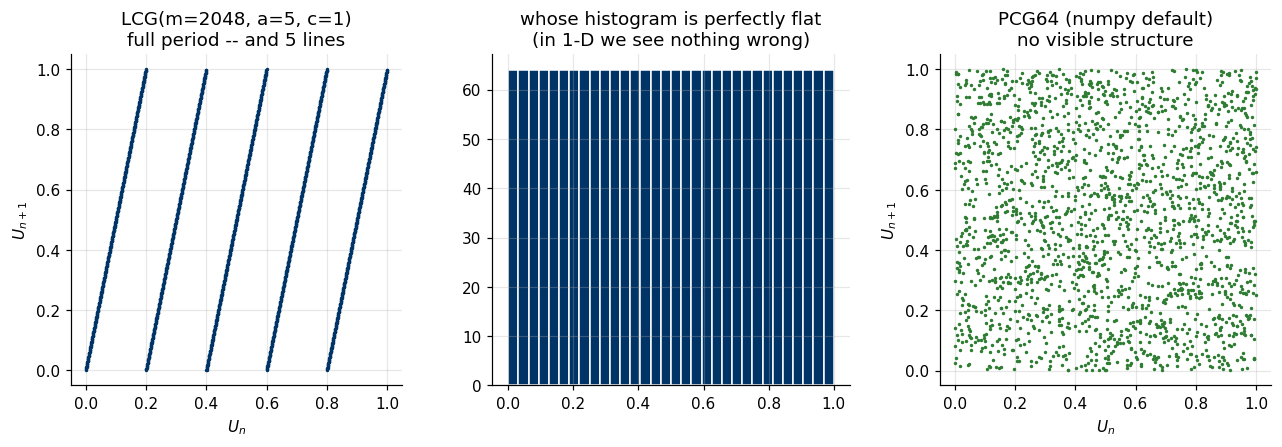

In [ ]:
# ------------------------------------------------------------------
# 2.1  Overlapping pairs: (U_n, U_{n+1}).  A "good enough" LCG in 1-D can
#      still be a disaster in 2-D.
# ------------------------------------------------------------------

def pairs(u):
    """Shift u into overlapping consecutive pairs (U_n, U_{n+1})."""
    return u[:-1], u[1:]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# (a) A small full-period LCG (Hull-Dobell: 5 = 1 mod 4, gcd(1,2048)=1).
#     Every one of the 2048 states appears exactly once -- and they land on 5 lines.

u_bad = lcg(2048, m=2048, a=5, c=1, seed=1)
ax[0].plot(*pairs(u_bad), ".", ms=2.5, color=BLUE)
ax[0].set_title("LCG(m=2048, a=5, c=1)\nfull period -- and 5 lines")

# (b) The very same numbers, viewed one at a time:
ax[1].hist(u_bad, bins=32, range=(0, 1), color=BLUE, edgecolor="white")
ax[1].set_title("whose histogram is perfectly flat\n(in 1-D we see nothing wrong)")

# (c) A modern PRNG for comparison:
u_mt = rng.random(2048)
ax[2].plot(*pairs(u_mt), ".", ms=2.5, color=GREEN)
ax[2].set_title("PCG64 (numpy default)\nno visible structure")

for a_ in (ax[0], ax[2]):
    a_.set_xlabel("$U_n$"); a_.set_ylabel("$U_{n+1}$"); a_.set_aspect("equal")
plt.tight_layout(); plt.show()

In [ ]:
# ------------------------------------------------------------------
# 2.2  The lattice is EXACT, not approximate. Measure it.
#      For X_{n+1} = (a X_n + c) mod m we have  a*U_n - U_{n+1} + c/m  in Z.
# ------------------------------------------------------------------
rows = []
for a_ in [5, 13, 65, 257]:              # all are 1 mod 4, so all have full period 2048
    u = lcg(2048, 2048, a_, 1, seed=1)
    w = a_ * u[:-1] - u[1:] + 1 / 2048   # must be an integer for EVERY n
    rows.append({"a": a_,
                 "distinct lines": len(np.unique(np.round(w))),
                 "worst deviation from an integer": f"{np.abs(w - np.round(w)).max():.1e}"})
display(pd.DataFrame(rows))

print("A bigger multiplier buys more lines, i.e. a finer lattice, but never removes it.")

,a,distinct lines,worst deviation from an integer
0,5,5,0.0e+00
1,13,13,0.0e+00
2,65,65,0.0e+00
3,257,257,0.0e+00


A bigger multiplier buys more lines, i.e. a finer lattice, but never removes it.


---
# Part 3 - The Inverse Transform Method

**Theorem (Probability Integral Transform).** If $F$ is a continuous, strictly increasing
CDF and $U \sim \mathrm{Uniform}(0,1)$, then $X = F^{-1}(U)$ has CDF $F$:

$$P(X \le x) = P\big(F^{-1}(U) \le x\big) = P\big(U \le F(x)\big) = F(x).$$

**Algorithm.** (1) draw $U \sim U(0,1)$; (2) return $X = F^{-1}(U)$. That is the whole method.

From here on we use a *trusted* uniform stream (`rng.random`) rather than our toy LCG —
Part 2 was the argument for why. Everything below would work identically with any good
uniform generator

In [ ]:
# ------------------------------------------------------------------
# 3.1  One reusable validator, used for every continuous example below.
#      It compares OUR samples against scipy's implementation of the same
#      distribution -- an independent check of our hand-derived F^{-1}.
# ------------------------------------------------------------------

def check_continuous(samples, dist, name, xlim=None, bins=60):
    """Histogram vs true pdf, Q-Q plot, and a Kolmogorov-Smirnov test."""
    lo, hi = xlim if xlim is not None else (np.min(samples), np.max(samples))
    grid = np.linspace(lo, hi, 400)

    fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))

    # (a) empirical density vs the true density
    ax[0].hist(samples, bins=bins, range=(lo, hi), density=True,
               color=BLUE, edgecolor="white", alpha=0.85, label="inverse transform")
    ax[0].plot(grid, dist.pdf(grid), color=ORANGE, lw=2.2, label="true pdf")
    ax[0].set_title(f"{name}: density check")
    ax[0].set_xlabel("x"); ax[0].legend(fontsize=8)

    # (b) Q-Q plot: sample quantiles vs theoretical quantiles (should be the 45-degree line)
    p = (np.arange(1, 201) - 0.5) / 200
    ax[1].plot(dist.ppf(p), np.quantile(samples, p), ".", ms=4, color=BLUE)
    lim = [max(lo, dist.ppf(0.001)), min(hi, dist.ppf(0.999))]
    ax[1].plot(lim, lim, "--", color=ORANGE, lw=1.5)
    ax[1].set_title(f"{name}: Q-Q plot")
    ax[1].set_xlabel("theoretical quantile"); ax[1].set_ylabel("sample quantile")
    ax[1].set_xlim(lim); ax[1].set_ylim(lim)

    plt.tight_layout(); plt.show()

N = 100000          # sample size used

### 3.1 Example 1 — Exponential $(\lambda)$

$$F(x) = 1 - e^{-\lambda x}, \; x\ge 0
\;\;\Longrightarrow\;\;
u = 1-e^{-\lambda x}
\;\;\Longrightarrow\;\;
X = -\frac{\ln(1-U)}{\lambda}.$$

Because $U \sim U(0,1) \Rightarrow 1-U \sim U(0,1)$, the cheaper form $X = -\ln(U)/\lambda$
is equally valid.

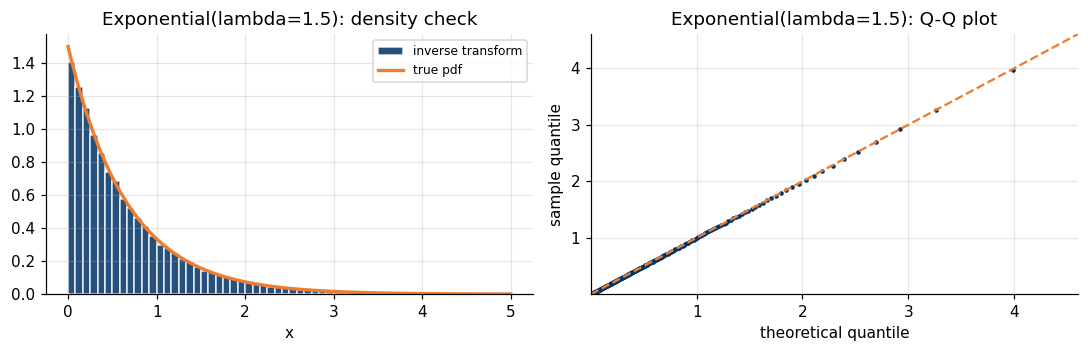

In [ ]:
# ------------------------------------------------------------------
# 3.2  Exponential(lambda) by inverse transform.
# ------------------------------------------------------------------
lam = 1.5

x_exp  = -np.log(1 - rng.random(N)) / lam    # textbook form

check_continuous(x_exp, stats.expon(scale=1 / lam), f"Exponential(lambda={lam})",
                 xlim=(0, 5))

### 3.2 Examples 2–4 — Cauchy, Weibull, Pareto

| Distribution | CDF $F(x)$ | Inverse $F^{-1}(u)$ |
|:--|:--|:--|
| Standard Cauchy | $\tfrac12 + \tfrac1\pi \arctan x$ | $\tan\!\big(\pi(u - \tfrac12)\big)$ |
| Weibull $(\alpha,\beta)$ | $1 - e^{-(x/\beta)^\alpha}$ | $\beta\big(-\ln(1-u)\big)^{1/\alpha}$ |
| Pareto $(x_m,\alpha)$ | $1 - (x_m/x)^\alpha,\; x \ge x_m$ | $x_m\,(1-u)^{-1/\alpha}$ |

Each is a two-line derivation: write $u = F(x)$, solve for $x$. Note that Exponential is
the special case $\alpha = 1$ of Weibull

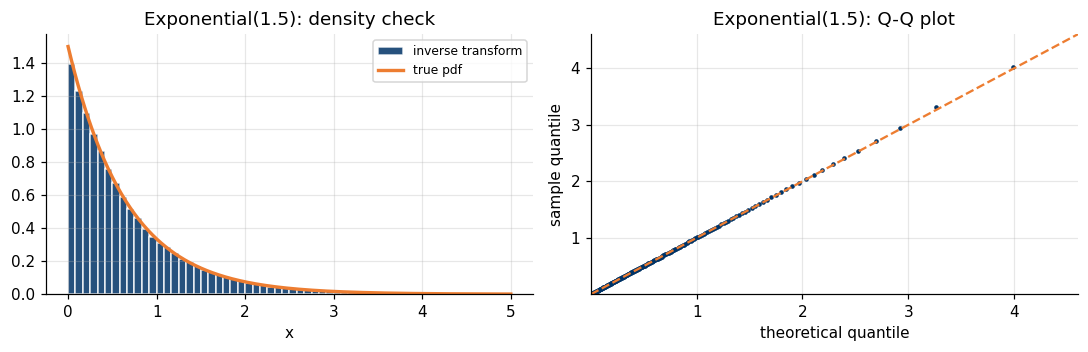

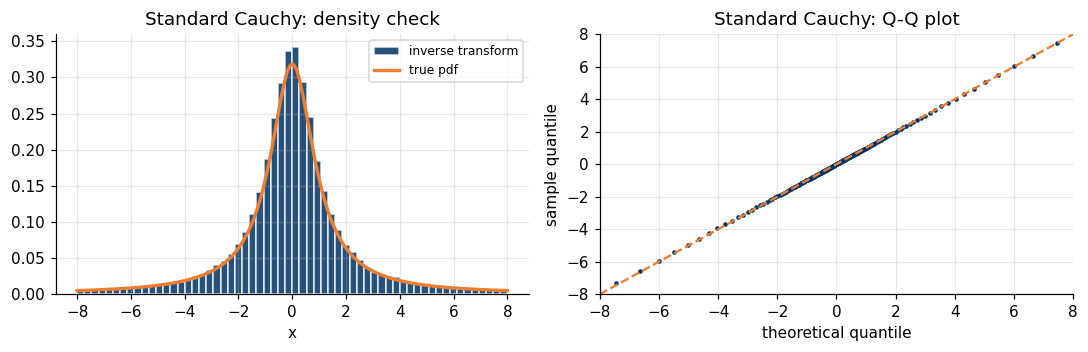

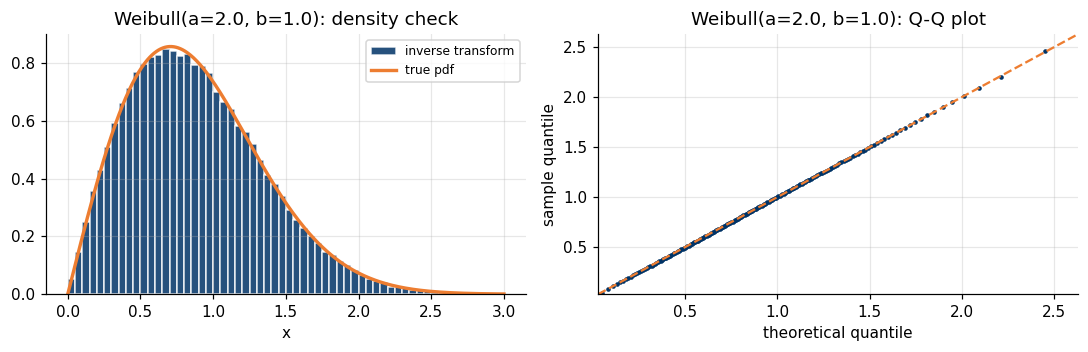

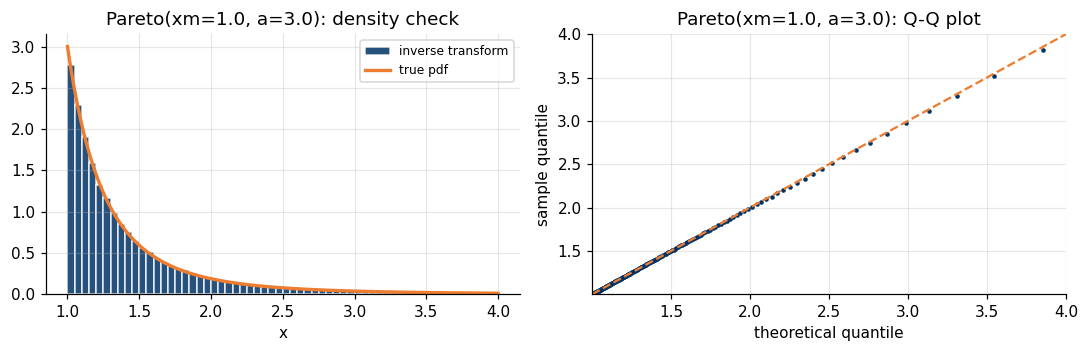

In [ ]:
# ------------------------------------------------------------------
# 3.2  All four continuous examples in one place.
#      Each entry: (our sampler F^{-1}, scipy's version for validation).
# ------------------------------------------------------------------
alpha_w, beta_w = 2.0, 1.0        # Weibull shape, scale
alpha_p, xm_p   = 3.0, 1.0        # Pareto shape, minimum

examples = {
    "Exponential(1.5)": (
        lambda u: -np.log(1 - u) / 1.5,
        stats.expon(scale=1 / 1.5),
        (0, 5),
    ),
    "Standard Cauchy": (
        lambda u: np.tan(np.pi * (u - 0.5)),
        stats.cauchy(),
        (-8, 8),                                   # clipped: the true support is all of R
    ),
    f"Weibull(a={alpha_w}, b={beta_w})": (
        lambda u: beta_w * (-np.log(1 - u)) ** (1 / alpha_w),
        stats.weibull_min(c=alpha_w, scale=beta_w),
        (0, 3),
    ),
    f"Pareto(xm={xm_p}, a={alpha_p})": (
        lambda u: xm_p / (1 - u) ** (1 / alpha_p),
        stats.pareto(b=alpha_p, scale=xm_p),
        (1, 4),
    ),
}

results = {}
for name, (finv, dist, xlim) in examples.items():
    u = rng.random(N)                 # fresh uniforms
    x = finv(u)                       # ONE line: the inverse transform
    results[name] = x
    check_continuous(x, dist, name, xlim=xlim)

### 3.3 The discrete case

For $X$ taking values $x_1 < x_2 < \cdots$ with $P(X = x_i) = p_i$, the CDF is a step
function and the method becomes a **lookup**: Divide $(0,1)$ into consecutive intervals
of lengths $p_1, p_2, \dots$ and see which one contains $U$.

**Algorithm.** Draw $U \sim U(0,1)$; return $x_i$ for the smallest $i$ with
$U \le F(x_i) = \sum_{j \le i} p_j$.

A binary search (`np.searchsorted`) is being used

In [ ]:
# ------------------------------------------------------------------
# 3.3  Generic discrete inverse transform + the categorical example
#      from the slides:  P(1)=0.2, P(2)=0.5, P(3)=0.3.
# ------------------------------------------------------------------

def discrete_inverse_transform(u, values, probs):
    """Return X = x_i for the smallest i with u <= F(x_i). Vectorised over u."""
    values = np.asarray(values)
    cdf = np.cumsum(probs)
    cdf[-1] = 1.0                       # guard against 0.999999... from rounding
    # side='left' gives the first index j with cdf[j] >= u  <=>  smallest i with u <= F(x_i)
    idx = np.searchsorted(cdf, u, side="left")
    return values[np.clip(idx, 0, len(values) - 1)]

# --- the slide example -------------------------------------------------
vals, probs = [1, 2, 3], [0.2, 0.5, 0.3]
u = rng.random(N)
x_cat = discrete_inverse_transform(u, vals, probs)

emp = [(x_cat == v).mean() for v in vals]
display(pd.DataFrame({"value": vals, "target p": probs, "empirical": np.round(emp, 4),
                      "U falls in": ["[0, 0.2)", "[0.2, 0.7)", "[0.7, 1)"]}))

,value,target p,empirical,U falls in
0,1,0.2,0.2013,"[0, 0.2)"
1,2,0.5,0.4995,"[0.2, 0.7)"
2,3,0.3,0.2992,"[0.7, 1)"


### 3.4 Binomial $(n, p)$ by inverse transform

There is no closed-form $F^{-1}$, but the support is finite, so we simply **build the
table**:

$$p_k = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0,\dots,n,$$

form the cumulative sums once, and reuse them for every draw.

pmf sums to 1.000000000000


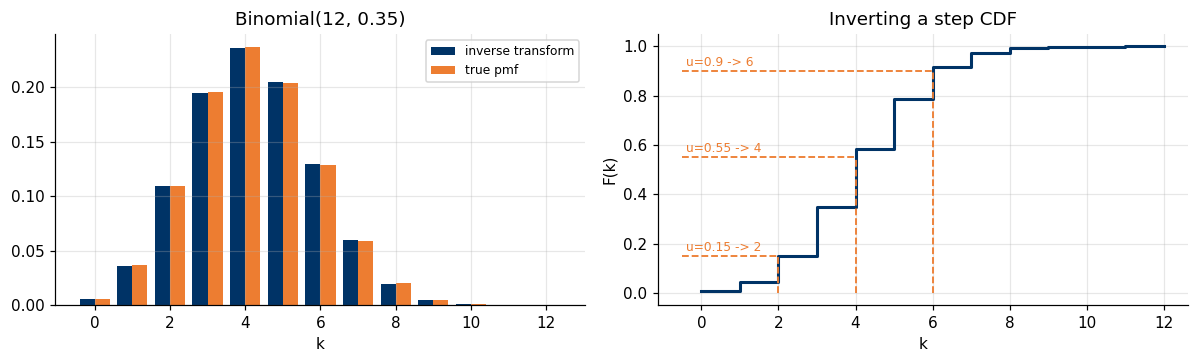

In [ ]:
# ------------------------------------------------------------------
# 3.4  Binomial(n, p) via a cumulative-probability table.
# ------------------------------------------------------------------
n_bin, p_bin = 12, 0.35

k_vals = np.arange(n_bin + 1)
# pmf built from the definition (math.comb)
pmf_bin = np.array([math.comb(n_bin, k) * p_bin**k * (1 - p_bin)**(n_bin - k)
                    for k in k_vals])
print(f"pmf sums to {pmf_bin.sum():.12f}")

x_bin = discrete_inverse_transform(rng.random(N), k_vals, pmf_bin)

# --- validation ---------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))

emp = np.array([(x_bin == k).mean() for k in k_vals])
ax[0].bar(k_vals - 0.2, emp, width=0.4, color=BLUE, label="inverse transform")
ax[0].bar(k_vals + 0.2, stats.binom.pmf(k_vals, n_bin, p_bin), width=0.4,
          color=ORANGE, label="true pmf")
ax[0].set_xlabel("k"); ax[0].set_title(f"Binomial({n_bin}, {p_bin})")
ax[0].legend(fontsize=8)

# (0,1) divided into intervals of length p_k.
cdf_bin = np.cumsum(pmf_bin)
ax[1].step(np.repeat(k_vals, 2)[1:], np.repeat(cdf_bin, 2)[:-1], where="post",
           color=BLUE, lw=2)
for q in [0.15, 0.55, 0.9]:
    k_hit = k_vals[np.searchsorted(cdf_bin, q, side="left")]
    ax[1].hlines(q, -0.5, k_hit, color=ORANGE, lw=1.2, ls="--")
    ax[1].vlines(k_hit, 0, q, color=ORANGE, lw=1.2, ls="--")
    ax[1].text(-0.4, q + 0.02, f"u={q} -> {k_hit}", fontsize=8, color=ORANGE)
ax[1].set_xlabel("k"); ax[1].set_ylabel("F(k)")
ax[1].set_title("Inverting a step CDF")

plt.tight_layout(); plt.show()

---
# Part 4 - The Acceptance–Rejection Method

When $F^{-1}$ is unavailable (like the Normal) or the target is known only up to a constant
(every Bayesian posterior you will meet in Module 5), we throw darts instead.

**Setup.** Target density $f$; an easy-to-sample **envelope** $g$; a constant $c \ge 1$ with

$$f(x) \le c\,g(x) \quad \text{for all } x, \qquad c = \sup_x \frac{f(x)}{g(x)}.$$

**Algorithm.** Draw $Y \sim g$ and $U \sim U(0,1)$ independently. Accept $X = Y$ if

$$U \le \frac{f(Y)}{c\,g(Y)},$$

otherwise discard and repeat.

**Two facts to remember.**

1. *Correctness.* Conditional on acceptance, $Y$ has exactly density $f$ — the envelope $g$
   cancels in the proof, so **any** valid $(g, c)$ gives the right answer.
2. *Efficiency.* $P(\text{accept}) = 1/c$, and the number of proposals per accepted draw is
   $\mathrm{Geometric}(1/c)$ with mean $c$. So $g$ and $c$ do not affect correctness at all —
   only cost. Choosing them well is the entire play.

In [ ]:
# ------------------------------------------------------------------
# 4.1
# -------------------------------------------------------------

def accept_reject(n, target_pdf, proposal_sample, proposal_pdf, c, rng, batch=None):
    """Draw n samples from target_pdf using the envelope c * proposal_pdf.

    Returns
    -------
    samples : array of length n, distributed as target_pdf
    info    : dict with n_proposals, acceptance_rate, and trials-per-acceptance
    """
    if batch is None:
        batch = max(1000, int(n * c * 1.2))     # expect ~c proposals per acceptance

    ys, keeps, n_acc = [], [], 0
    while n_acc < n:
        y = proposal_sample(batch)               # Step 1: Y ~ g
        u = rng.random(batch)                    # Step 2: U ~ U(0,1)
        ratio = target_pdf(y) / (c * proposal_pdf(y))
        if np.nanmax(ratio) > 1 + 1e-9:          # c is too small => the method is INVALID
            print(f"  WARNING: f/(c*g) reached {np.nanmax(ratio):.4f} > 1. "
                  f"c = {c} is not an upper bound; samples will be biased.")
        keep = u <= ratio                        # Step 3: accept or reject
        ys.append(y); keeps.append(keep)
        n_acc += int(keep.sum())

    y = np.concatenate(ys); keep = np.concatenate(keeps)
    idx = np.flatnonzero(keep)[:n]               # positions of the first n acceptances
    n_prop = int(idx[-1]) + 1                    # proposals consumed to get them
    trials = np.diff(np.concatenate(([-1], idx)))  # proposals used per acceptance
    info = {"n_proposals": n_prop, "acceptance_rate": n / n_prop, "trials": trials}
    return y[idx], info

### 4.2 Example 1 - Normal from Cauchy

The Normal has no closed-form $F^{-1}$, so we build it out of a Cauchy, which does
(Part 3.3). The Cauchy is the natural envelope here: its **tails are heavier** than the
Normal's, so the ratio stays bounded.

$$\frac{f(x)}{g(x)}
= \frac{\frac{1}{\sqrt{2\pi}} e^{-x^2/2}}{\frac{1}{\pi (1+x^2)}}
= \sqrt{\frac{\pi}{2}}\,(1+x^2)\,e^{-x^2/2}.$$

Differentiate: $\frac{d}{dx}\big[(1+x^2)e^{-x^2/2}\big] = x(1-x^2)e^{-x^2/2}$, which
vanishes at $x = 0, \pm 1$. The maximum is at $x = \pm 1$, giving

$$c = \sqrt{\frac{\pi}{2}} \cdot 2e^{-1/2} \approx 1.5203,
\qquad P(\text{accept}) = \frac1c \approx 0.6577 .$$

About one proposal in three is wasted — a very good deal for a distribution with no
invertible CDF.

c (analytic) = 1.520347
c (numeric ) = 1.520347   at x = -1.000
theoretical acceptance rate 1/c = 0.6577
empirical  acceptance rate      = 0.6591


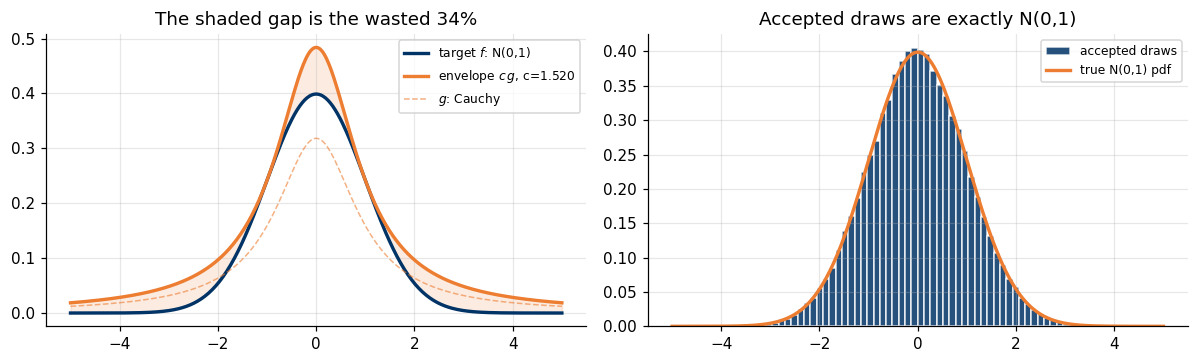

In [ ]:
# ------------------------------------------------------------------
# 4.2  Normal(0,1) from a Cauchy envelope.
# ------------------------------------------------------------------
f_normal = lambda x: np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)     # target
g_cauchy = lambda x: 1 / (np.pi * (1 + x**2))                   # envelope
# Cauchy draws come from OUR Part-3 inverse transform, not from scipy:
sample_cauchy = lambda k: np.tan(np.pi * (rng.random(k) - 0.5))

c_theory = math.sqrt(math.pi / 2) * 2 * math.exp(-0.5)

# Confirm the analytic sup numerically before trusting it.
grid = np.linspace(-12, 12, 200_001)
c_numeric = np.max(f_normal(grid) / g_cauchy(grid))
print(f"c (analytic) = {c_theory:.6f}")
print(f"c (numeric ) = {c_numeric:.6f}   at x = {grid[np.argmax(f_normal(grid)/g_cauchy(grid))]:+.3f}")
print(f"theoretical acceptance rate 1/c = {1/c_theory:.4f}")

x_ar, info = accept_reject(N, f_normal, sample_cauchy, g_cauchy, c_theory, rng)
print(f"empirical  acceptance rate      = {info['acceptance_rate']:.4f}")

# --- picture + validation -----------------------------------------
xs = np.linspace(-5, 5, 400)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))

ax[0].plot(xs, f_normal(xs), color=BLUE, lw=2.2, label="target $f$: N(0,1)")
ax[0].plot(xs, c_theory * g_cauchy(xs), color=ORANGE, lw=2.2,
           label=f"envelope $c\\,g$, c={c_theory:.3f}")
ax[0].plot(xs, g_cauchy(xs), "--", color=ORANGE, lw=1, alpha=0.6, label="$g$: Cauchy")
ax[0].fill_between(xs, f_normal(xs), c_theory * g_cauchy(xs),
                   color=ORANGE, alpha=0.15)
ax[0].set_title("The shaded gap is the wasted 34%")
ax[0].legend(fontsize=8)

ax[1].hist(x_ar, bins=70, range=(-4.5, 4.5), density=True, color=BLUE,
           edgecolor="white", alpha=0.85, label="accepted draws")
ax[1].plot(xs, f_normal(xs), color=ORANGE, lw=2.2, label="true N(0,1) pdf")
ax[1].set_title("Accepted draws are exactly N(0,1)")
ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

### 4.3 Example 2 - Beta $(2,2)$ from a Uniform envelope (slide 22)

Target $f(x) = 6x(1-x)$ on $[0,1]$; envelope $g(x) = 1$, the simplest proposal there is.

$$c = \sup_{0\le x \le 1} 6x(1-x) = 6\cdot\tfrac12\cdot\tfrac12 = 1.5 \quad (\text{at } x = 0.5),$$

so the acceptance step is $U \le \dfrac{6Y(1-Y)}{1.5} = 4Y(1-Y)$, and we expect
$1/1.5 = 66.7\%$ acceptance.

theoretical acceptance = 0.6667
empirical   acceptance = 0.6659


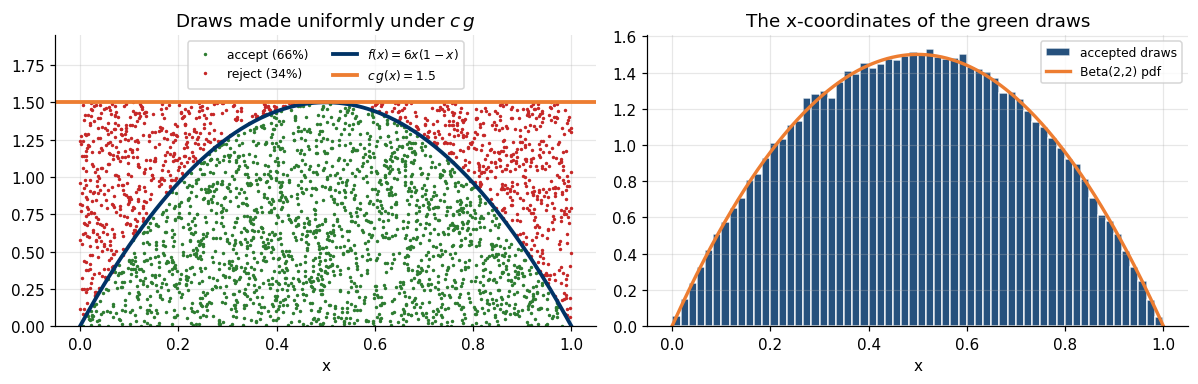

In [ ]:
# ------------------------------------------------------------------
# 4.3  Beta(2,2) from Uniform(0,1)
# ------------------------------------------------------------------
f_beta = lambda x: 6 * x * (1 - x)
g_unif = lambda x: np.ones_like(x)
sample_unif = lambda k: rng.random(k)
c_beta = 1.5

x_beta, info_beta = accept_reject(N, f_beta, sample_unif, g_unif, c_beta, rng)
print(f"theoretical acceptance = {1/c_beta:.4f}")
print(f"empirical   acceptance = {info_beta['acceptance_rate']:.4f}")

# --- the draws ----------------------------------------------------
n_show = 3000
Y = rng.random(n_show)
U = rng.random(n_show)
height = U * c_beta * g_unif(Y)                 # the dart's height under the envelope
acc = height <= f_beta(Y)                       # equivalent to U <= f(Y)/(c g(Y))

xs = np.linspace(0, 1, 300)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].plot(Y[acc], height[acc], ".", ms=2.5, color=GREEN, label=f"accept ({acc.mean():.0%})")
ax[0].plot(Y[~acc], height[~acc], ".", ms=2.5, color="#C62828",
           label=f"reject ({1-acc.mean():.0%})")
ax[0].plot(xs, f_beta(xs), color=BLUE, lw=2.5, label="$f(x)=6x(1-x)$")
ax[0].axhline(c_beta, color=ORANGE, lw=2.5, label="$c\\,g(x)=1.5$")
ax[0].set_ylim(0, 1.95)                          # headroom so the legend clears the darts
ax[0].set_title("Draws made uniformly under $c\\,g$")
ax[0].set_xlabel("x"); ax[0].legend(fontsize=8, loc="upper center", ncol=2)

ax[1].hist(x_beta, bins=60, density=True, color=BLUE, edgecolor="white", alpha=0.85,
           label="accepted draws")
ax[1].plot(xs, f_beta(xs), color=ORANGE, lw=2.2, label="Beta(2,2) pdf")
ax[1].set_title("The x-coordinates of the green draws")
ax[1].set_xlabel("x"); ax[1].legend(fontsize=8)

plt.tight_layout();
plt.show()

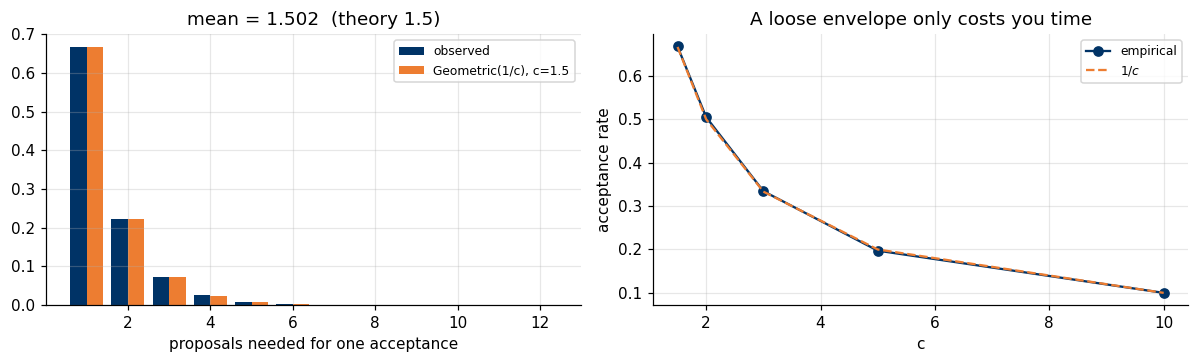

,c,1/c (theory),empirical acceptance,proposals for 20k draws
0,1.5,0.666667,0.6677,29952
1,2.0,0.500000,0.5049,39614
2,3.0,0.333333,0.3344,59807
3,5.0,0.200000,0.1973,101382
4,10.0,0.100000,0.1000,199985


Every row is still a valid Beta(2,2) sample: inflating c
does not bias anything, it just wastes draws. Under-stating c is the fatal error.


In [ ]:
# ------------------------------------------------------------------
# 4.4  Efficiency: the number of proposals per acceptance is Geometric(1/c).
# ------------------------------------------------------------------
trials = info_beta["trials"]
kk = np.arange(1, 13)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))

ax[0].bar(kk - 0.2, [(trials == k).mean() for k in kk], width=0.4, color=BLUE,
          label="observed")
ax[0].bar(kk + 0.2, stats.geom.pmf(kk, 1 / c_beta), width=0.4, color=ORANGE,
          label=f"Geometric(1/c), c={c_beta}")
ax[0].set_xlabel("proposals needed for one acceptance")
ax[0].set_title(f"mean = {trials.mean():.3f}  (theory {c_beta})")
ax[0].legend(fontsize=8)

# Deliberately loosen the envelope: correctness is untouched.
cs = [1.5, 2.0, 3.0, 5.0, 10.0]
rows = []
for cc in cs:
    xb, ib = accept_reject(20_000, f_beta, sample_unif, g_unif, cc, rng)
    rows.append({"c": cc, "1/c (theory)": 1 / cc,
                 "empirical acceptance": round(ib["acceptance_rate"], 4),
                 "proposals for 20k draws": ib["n_proposals"]})
df = pd.DataFrame(rows)

ax[1].plot(df["c"], df["empirical acceptance"], "o-", color=BLUE, label="empirical")
ax[1].plot(df["c"], 1 / df["c"], "--", color=ORANGE, label="$1/c$")
ax[1].set_xlabel("c"); ax[1].set_ylabel("acceptance rate")
ax[1].set_title("A loose envelope only costs you time")
ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()
display(df)
print("Every row is still a valid Beta(2,2) sample: inflating c")
print("does not bias anything, it just wastes draws. Under-stating c is the fatal error.")

### 4.5 Example 3 - Normal truncated to $[a,\infty)$ (slide 23)

Sampling the far tail is the rare-event problem in miniature. The naive approach —
draw $Z \sim N(0,1)$, keep it if $Z \ge a$ — has acceptance probability
$P(Z \ge a) = 1 - \Phi(a)$, which is catastrophic for large $a$ (about $3\times 10^{-5}$
at $a = 4$).

Instead use a **shifted exponential** on $[a,\infty)$:
$g(x) = \lambda e^{-\lambda(x-a)}$, sampled as $X = a - \ln(U)/\lambda$. Then for
$\lambda \ge a$,

$$\frac{f(x)}{g(x)} = \frac{e^{-x^2/2}\,e^{\lambda(x-a)}}{\lambda\sqrt{2\pi}\,(1-\Phi(a))}
\quad\text{is maximised at } x = \lambda,
\qquad
c(\lambda) = \frac{e^{\lambda^2/2-\lambda a}}{\lambda\sqrt{2\pi}\,(1-\Phi(a))}.$$

The slides take $\lambda = a$, giving the tidy $c = \phi(a)\big/\big[a(1-\Phi(a))\big]$.

In [ ]:
# ------------------------------------------------------------------
# 4.5  Truncated Normal on [a, inf): naive rejection vs an exponential envelope.
# ------------------------------------------------------------------
def c_trunc(a, lam):
    """sup over x >= a of f/g for the shifted-exponential envelope."""
    x_star = max(lam, a)                          # interior max at lam, else the boundary a
    log_c = (-x_star**2 / 2 + lam * (x_star - a)
             - math.log(lam) - 0.5 * math.log(2 * math.pi)
             - math.log(stats.norm.sf(a)))        # sf(a) = 1 - Phi(a), accurate in the tail
    return math.exp(log_c)


# --- how the two envelopes compare as the truncation point moves out ---
rows = []
for a in [0.5, 1, 2, 3, 4, 5]:
    naive = stats.norm.sf(a)                      # acceptance rate of naive rejection
    rows.append({
        "a": a,
        "naive acceptance": f"{naive:.3e}",
        "naive draws per sample": f"{1/naive:,.0f}",
        "exp envelope, lam=a": f"{1/c_trunc(a, max(a, 1e-6)):.4f}"
    })
display(pd.DataFrame(rows))
print("At a=4 the naive method needs ~30,000 Normal draws per accepted value.")
print("The exponential envelope needs about 0.9")

,a,naive acceptance,naive draws per sample,"exp envelope, lam=a"
0,0.5,3.085e-01,3,0.4382
1,1.0,1.587e-01,6,0.6557
2,2.0,2.275e-02,44,0.8427
3,3.0,1.350e-03,741,0.9138
4,4.0,3.167e-05,"31,574",0.9466
5,5.0,2.867e-07,"3,488,556",0.9640


At a=4 the naive method needs ~30,000 Normal draws per accepted value.
The exponential envelope needs about 0.9


a = 3.0,  lambda = 3.0000,  c = 1.0944,  expected acceptance = 0.9138
empirical acceptance = 0.9135
naive method would have accepted only 1.350e-03 of its draws (741 draws per sample)


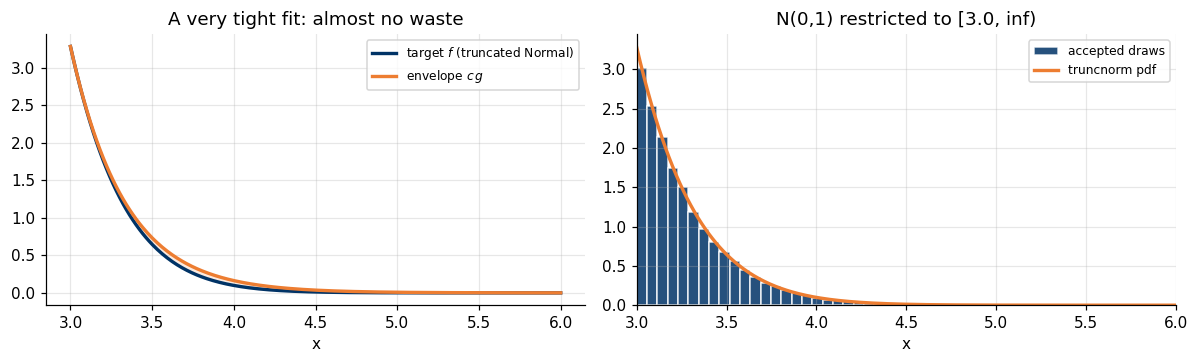

In [ ]:
# ------------------------------------------------------------------
# 4.5b  Run it: sample N(0,1) truncated to [a, inf) with a = 3.
# ------------------------------------------------------------------
a_trunc = 3.0
lam = a_trunc
c_tn = c_trunc(a_trunc, lam)
Z = stats.norm.sf(a_trunc)                        # normalising constant 1 - Phi(a)

f_tn = lambda x: np.exp(-x**2 / 2) / (np.sqrt(2 * np.pi) * Z)      # truncated Normal pdf
g_tn = lambda x: lam * np.exp(-lam * (x - a_trunc))                # shifted Exponential pdf
sample_shifted_exp = lambda k: a_trunc - np.log(rng.random(k)) / lam   # inverse transform!

print(f"a = {a_trunc},  lambda = {lam:.4f},  c = {c_tn:.4f},  "
      f"expected acceptance = {1/c_tn:.4f}")

x_tn, info_tn = accept_reject(N, f_tn, sample_shifted_exp, g_tn, c_tn, rng)
print(f"empirical acceptance = {info_tn['acceptance_rate']:.4f}")
print(f"naive method would have accepted only {Z:.3e} of its draws "
      f"({1/Z:,.0f} draws per sample)")

# --- validation against scipy's truncnorm --------------------------
tn = stats.truncnorm(a_trunc, np.inf)
xs = np.linspace(a_trunc, a_trunc + 3, 300)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(xs, f_tn(xs), color=BLUE, lw=2.2, label="target $f$ (truncated Normal)")
ax[0].plot(xs, c_tn * g_tn(xs), color=ORANGE, lw=2.2, label="envelope $c\\,g$")
ax[0].fill_between(xs, f_tn(xs), c_tn * g_tn(xs), color=ORANGE, alpha=0.15)
ax[0].set_title("A very tight fit: almost no waste")
ax[0].set_xlabel("x"); ax[0].legend(fontsize=8)

ax[1].hist(x_tn, bins=70, density=True, color=BLUE, edgecolor="white", alpha=0.85,
           label="accepted draws")
ax[1].plot(xs, tn.pdf(xs), color=ORANGE, lw=2.2, label="truncnorm pdf")
ax[1].set_xlim(a_trunc, a_trunc + 3)
ax[1].set_title(f"N(0,1) restricted to [{a_trunc}, inf)")
ax[1].set_xlabel("x"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## Wrap-up

What Module 1 claims, now has been demonstrated:

 **A PRNG is purely arithmetic.**
 Fixed integers determine the whole sequence.

### References

* Ross, S. M. *Simulation*, 5th ed. — Chapters 4–5.
* Robert, C. P. & Casella, G. *Monte Carlo Statistical Methods*, 2nd ed. — Chapter 2.
* Marsaglia, G. (1968). Random numbers fall mainly in the planes. *PNAS* **61**(1), 25–28.
* Hull, T. E. & Dobell, A. R. (1962). Random number generators. *SIAM Review* **4**(3), 230–254.
* Robert, C. P. (1995). Simulation of truncated normal variables. *Statistics and Computing* **5**, 121–125.